## About the Notebook:

This analysis explores spatial and environmental factors associated with river water quality. Satellite imagery from climate variables, such as Potential Evapotranspiration (PET) were incorporated to provide broader environmental context around observed water quality conditions and reflect underlying climatic influences.

The analysis focuses on data collected between 2011 and 2015. Relevant satellite and climate features were retrieved using API-based access through the Microsoft Planetary Computer portal and combined with water quality observations. Together, these datasets support an exploratory assessment of three key water quality parameters: Total Alkalinity (TA), Electrical Conductance (EC), and Dissolved Reactive Phosphorus (DRP).

In this notebook I'll explore how spatial conditions and time affect water quality.

```%pip install geopandas folium seaborn watermark```

In [19]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import MultiPolygon, Point
import folium
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import contextily as ctx

sns.set_theme()

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

%load_ext watermark
%watermark -v
%watermark --iversions

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Python implementation: CPython
Python version       : 3.12.12
IPython version      : 9.4.0

seaborn   : 0.13.2
pandas    : 2.3.1
contextily: 1.7.0
folium    : 0.20.0
shapely   : 2.1.2
matplotlib: 3.10.5
geopandas : 1.1.2



In [2]:
df = pd.read_pickle('data/good_vs_bad.pkl')
# df = pd.read_csv('data/wq.csv')
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326"
)

# https://simplemaps.com/gis/country/za --> download shapefile
# https://simplemaps.com/static/svg/country/za/admin1/za_shp.zip
path_to_data = 'data/za_shp'
provinces = gpd.read_file(path_to_data, layer='za').to_crs("EPSG:4326")
provinces = provinces.rename(columns={'name':'province'}).sort_values(by='province')

I broke down and had to ask AI how to do the next step <a href="https://search.brave.com/ask?q=poly+geometry+column+attributes+geopandas&source=quick-answer-followup&quickAnswerKey=08b6a94cb59b797c37ab73c2288ac22f4a90&quickAnswerQuery=poly+geometry+column+attributes+geopandas&conversation=08b68984eb40a57f229ccbefc071d17a3b3c">here</a>, and promted it as such, "how to convert a list of polygon into a multipolygon".

In [3]:
# replace the Western Cape with just the main land part without PRINCE EDWARDS ISLANDS
new_polygon = provinces['geometry'].explode()[7][:1]
multipolygon = MultiPolygon(new_polygon)
provinces.loc[7, 'geometry'] = multipolygon
provinces

,id,province,source,geometry
3,ZAEC,Eastern Cape,https://simplemaps.com,"POLYGON ((24.14703 -31.78989, 24.15432 -31.758..."
2,ZAFS,Free State,https://simplemaps.com,"POLYGON ((25.46747 -30.61312, 25.43161 -30.592..."
8,ZAGP,Gauteng,https://simplemaps.com,"POLYGON ((28.25583 -26.8936, 28.24466 -26.8940..."
1,ZAKZN,KwaZulu-Natal,https://simplemaps.com,"POLYGON ((30.19597 -31.07789, 30.1925 -31.0729..."
4,ZALP,Limpopo,https://simplemaps.com,"POLYGON ((31.85649 -23.96296, 31.85623 -23.963..."
6,ZAMP,Mpumalanga,https://simplemaps.com,"POLYGON ((31.24471 -27.23259, 31.18764 -27.297..."
5,ZANW,North West,https://simplemaps.com,"POLYGON ((25.01349 -28.06821, 25.00512 -28.070..."
0,ZANC,Northern Cape,https://simplemaps.com,"POLYGON ((22.63695 -26.11428, 22.70516 -26.129..."
7,ZAWC,Western Cape,https://simplemaps.com,"MULTIPOLYGON (((17.76711 -31.15581, 17.76742 -..."


### Grouping water quality parameters by province and aggregate by taking the mean in each province

Evapotranspiration is the combined process of how moisture is transferred from land into the atmosphere.
This metric is often related to weather, climate & **water availability**.
- evaporation: water from the Earth's surface
- transpiration: water vapor from plants

Evapotranspiration measurements may reflect temperature, humidity and vegetation type in any given region.  
Normally Potential Evapotranspiration is measured in mm/day for our dataset.  

https://en.wikipedia.org/wiki/Potential_evapotranspiration  
https://planetarycomputer.microsoft.com/dataset/terraclimate#overview

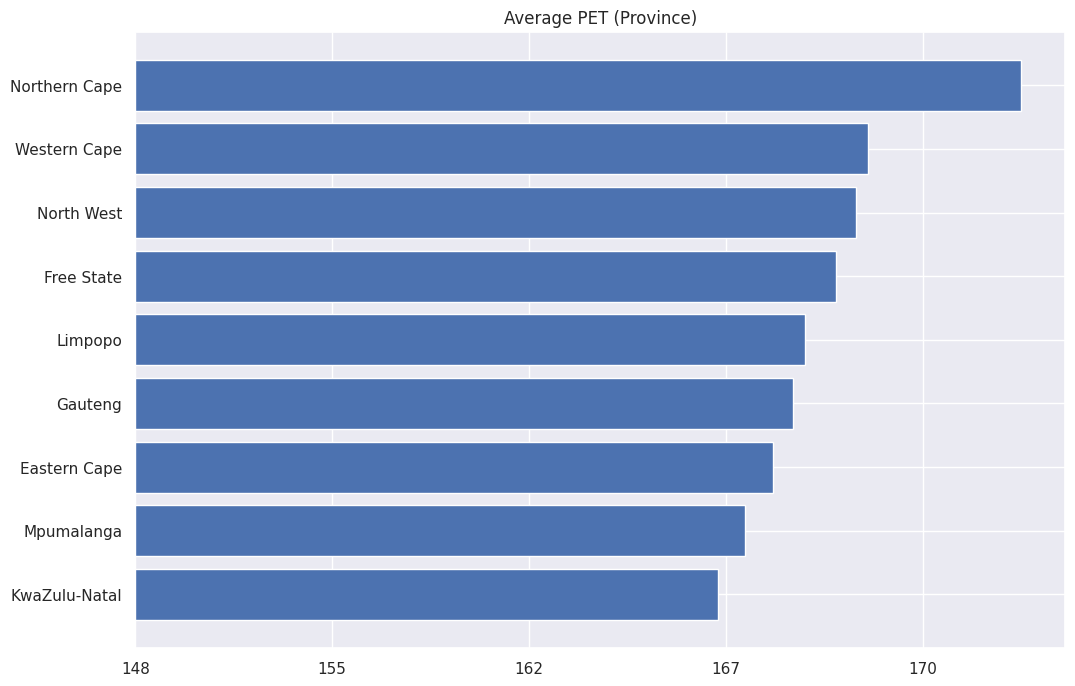

In [4]:
def piv(df, x='province', y='pet', by='province'):
    '''
    input
    -----
    x: str; column name of pandas dataframe
    y: str; column name of pandas dataframe

    returns
    -------
    pandas dataframe pivot grouped by x and values sorted by y
    '''
    df = df[[x, y]].groupby(x).mean().sort_values(by=by, ascending=True)
    # df = df.sort_values(by=y, ascending=True)
    df = df[y].round().astype(int)
    return df.reset_index()

#gdf[['province', 'electrical conductance']].groupby('province').mean().sort_values(by='province').reset_index()

def bar_horizontal(df, x='province', y='pet', title=str):
    '''
    input
    -----
    x: str; column name of pandas dataframe
    y: str; column name of pandas dataframe

    returns
    -------
    matplotlib horizontal bar plot
    '''
    fig, ax = plt.subplots(figsize=(12, 8))
    plt.barh(df[x], df[y].round().astype(int))
    ax.set_xticklabels(labels=df[y])
    plt.get_cmap('viridis')
    plt.title(title)

ax2 = bar_horizontal(piv(gdf, by='pet'), title='Average PET (Province)')

#### Wait...

Call the function again changing the 'y' parameter (```bar_horizontal(piv(gdf, y='pet', by='pet')```). 'y' and 'by' should be equal, so the bar graph will sort the provinces by value of the given parameter. Here are some inputs to choose from:

- 'nir'
- 'green'
- 'swir16'
- 'swir22'
- 'ndmi'
- 'mndwi'
- 'pet'
- 'total alkalinity'
- 'electrical conductance'
- 'dissolved reactive phosphorus'

In [5]:
# Group mean EC with each province (sort by province to 
province_group_EC = piv(df, x='province', y='electrical conductance', by='province')
province_group_EC

,province,electrical conductance
0,Eastern Cape,243
1,Free State,561
2,Gauteng,622
3,KwaZulu-Natal,240
4,Limpopo,475
5,Mpumalanga,374
6,North West,727
7,Northern Cape,633
8,Western Cape,494


In [6]:
# Add aggregated EC data to each provice
provinces = provinces.merge(province_group_EC, on='province')
provinces

,id,province,source,geometry,electrical conductance
0,ZAEC,Eastern Cape,https://simplemaps.com,"POLYGON ((24.14703 -31.78989, 24.15432 -31.758...",243
1,ZAFS,Free State,https://simplemaps.com,"POLYGON ((25.46747 -30.61312, 25.43161 -30.592...",561
2,ZAGP,Gauteng,https://simplemaps.com,"POLYGON ((28.25583 -26.8936, 28.24466 -26.8940...",622
3,ZAKZN,KwaZulu-Natal,https://simplemaps.com,"POLYGON ((30.19597 -31.07789, 30.1925 -31.0729...",240
4,ZALP,Limpopo,https://simplemaps.com,"POLYGON ((31.85649 -23.96296, 31.85623 -23.963...",475
5,ZAMP,Mpumalanga,https://simplemaps.com,"POLYGON ((31.24471 -27.23259, 31.18764 -27.297...",374
6,ZANW,North West,https://simplemaps.com,"POLYGON ((25.01349 -28.06821, 25.00512 -28.070...",727
7,ZANC,Northern Cape,https://simplemaps.com,"POLYGON ((22.63695 -26.11428, 22.70516 -26.129...",633
8,ZAWC,Western Cape,https://simplemaps.com,"MULTIPOLYGON (((17.76711 -31.15581, 17.76742 -...",494


In [7]:
# isolate all sample locations with "bad water quality"
bad = gdf[gdf['bad']==1]
bad.head()

,province,country,latitude,longitude,sample date,nir,green,swir16,swir22,ndmi,...,river_mouthORjunction,river_mouth,river_junction,DRP,EC,Alkalinity,how_good,good,bad,geometry
642,Limpopo,South Africa,-24.034167,31.123611,2011-06-15,14183.0,9801.0,13704.25,11265.25,0.021549,...,0,0,0,0,0,0,0,0,1,POINT (31.12361 -24.03417)
747,Northern Cape,South Africa,-28.376944,24.303056,2011-07-07,13126.5,10384.0,14884.50,12547.50,-0.062761,...,0,0,0,0,0,0,0,0,1,POINT (24.30306 -28.37694)
1042,Free State,South Africa,-27.398611,26.614722,2011-09-06,13482.5,9993.0,14245.50,12485.50,-0.027517,...,0,0,0,0,0,0,0,0,1,POINT (26.61472 -27.39861)
1298,North West,South Africa,-26.880278,26.965000,2011-11-01,14183.0,9801.0,13704.25,11265.25,0.021549,...,0,0,0,0,0,0,0,0,1,POINT (26.965 -26.88028)
1319,Free State,South Africa,-29.658056,25.973333,2011-11-05,13931.0,10447.0,14510.50,12488.00,-0.020375,...,0,0,0,0,0,0,0,0,1,POINT (25.97333 -29.65806)


### Total Alkalinity & Electrical Conductance

- Total Alkalinity
    - Resistance to pH fluctuation often measured by buffer concentrations of CaCO3 (or similar titrant) in milligrams per liter or ppm. 
    -  Ideal Range: 20 to 200 mg/L

- Electrical Conductance
    - Hoow easily electric current flows through a specific object or component measured in micro-Siemens per centimeter
    - Ideal Range: < 800 µS/cm

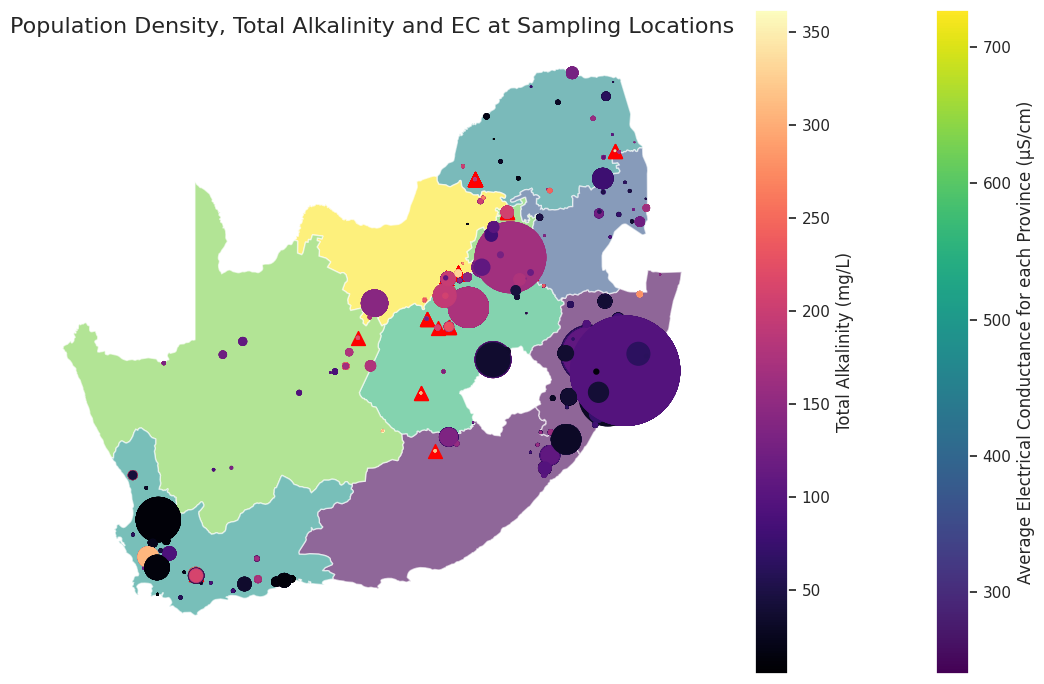

In [34]:
# Plot
fig, ax = plt.subplots(figsize=(11, 7))

provinces.plot(column='electrical conductance', ax=ax, zorder=1, cmap='viridis', alpha=0.6, legend=True, legend_kwds={'label':'Average Electrical Conductance for each Province (µS/cm)'})#, tootip={'province'})
gdf.plot(column='total alkalinity', ax=ax, marker='o', markersize=gdf['pop_density_nn'], zorder=2, cmap='magma', legend=True, legend_kwds={'label':'Total Alkalinity (mg/L)'})#, tootip={'pop_density_nn'})
bad.plot(column='bad', ax=ax, marker='^', markersize=100, color='red')

ax.set_axis_off()
plt.title('Population Density, Total Alkalinity and EC at Sampling Locations', fontsize=16)
plt.tight_layout()
plt.show()

#### It looks like Total Alkalinity and Electrical Conductance have a general positive correlation

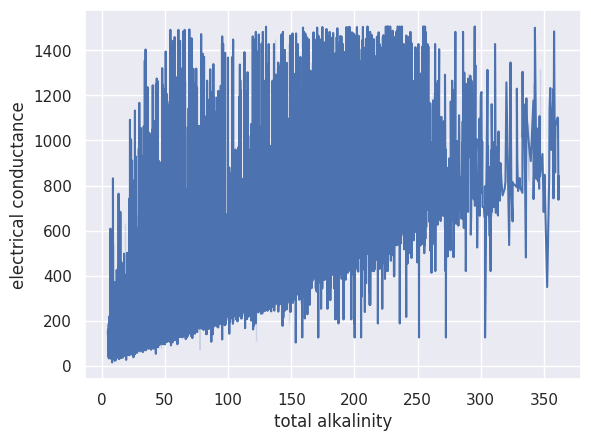

In [9]:
sns.lineplot(data=gdf, x="total alkalinity", y="electrical conductance");

### How are our parameters looking throughout time??

- LET's GO FOR SPEED!!!
- Here we can explore ways to analyze PET, and other water quality parameters if we want.

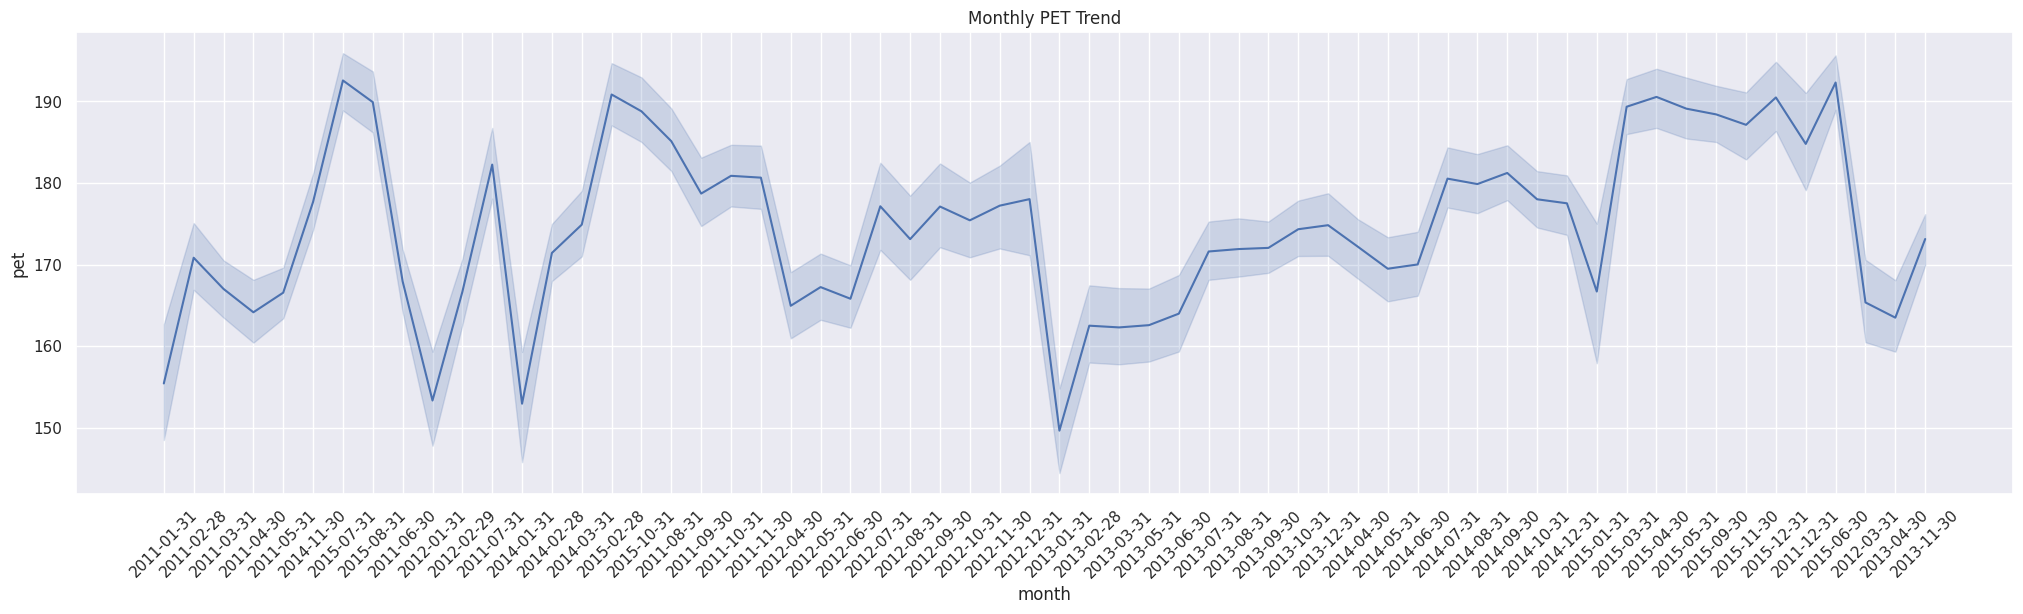

In [10]:
# Monthly time series vs PET
fig, ax = plt.subplots(figsize=(25, 6));
sns.lineplot(data=gdf, x="month", y="pet")
plt.xticks(rotation=45)
plt.title('Monthly PET Trend');

#### I see some outliers in the visualization below. It looks like there are 5 periods where PET drops unordinarily low.

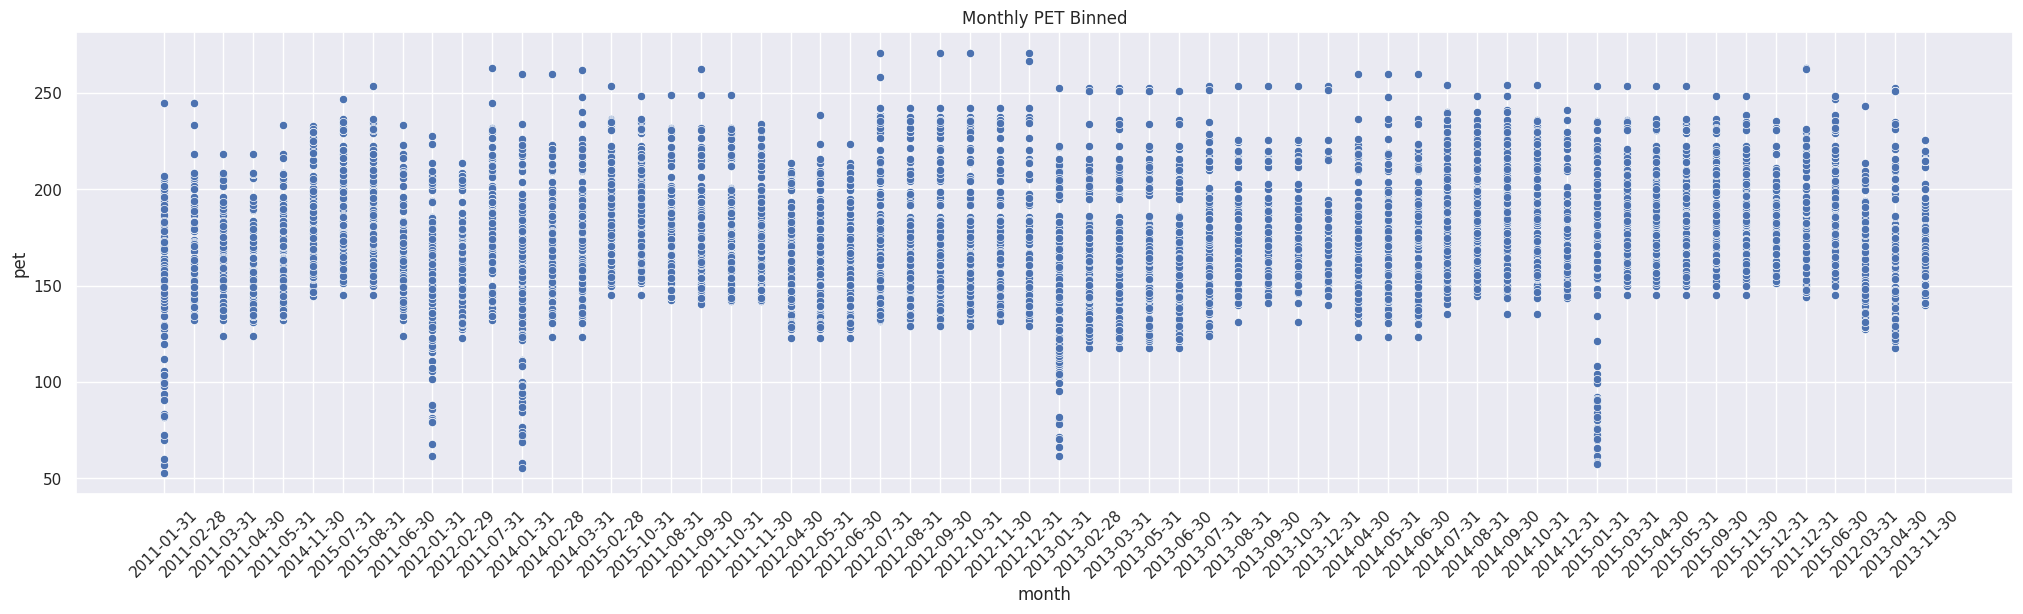

In [11]:
fig, ax = plt.subplots(figsize=(25, 6));
sns.scatterplot(data=gdf, x="month", y="pet")
plt.xticks(rotation=45)
plt.title('Monthly PET Binned');

In [12]:
gdf.columns

Index(['province', 'country', 'latitude', 'longitude', 'sample date', 'nir',
       'green', 'swir16', 'swir22', 'ndmi', 'mndwi', 'pet', 'total alkalinity',
       'electrical conductance', 'dissolved reactive phosphorus', 'month',
       'sample_year', 'pop_density_nn', 'distance_km_to_pd_cell',
       'river_mouthORjunction', 'river_mouth', 'river_junction', 'DRP', 'EC',
       'Alkalinity', 'how_good', 'good', 'bad', 'geometry'],
      dtype='object')

In [13]:
pivot_table = gdf[['nir', 'green','swir16', 'swir22', 'ndmi', 'mndwi', 'pet', 'total alkalinity',
       'electrical conductance', 'dissolved reactive phosphorus', 'month']].groupby('month').sum().astype(int)

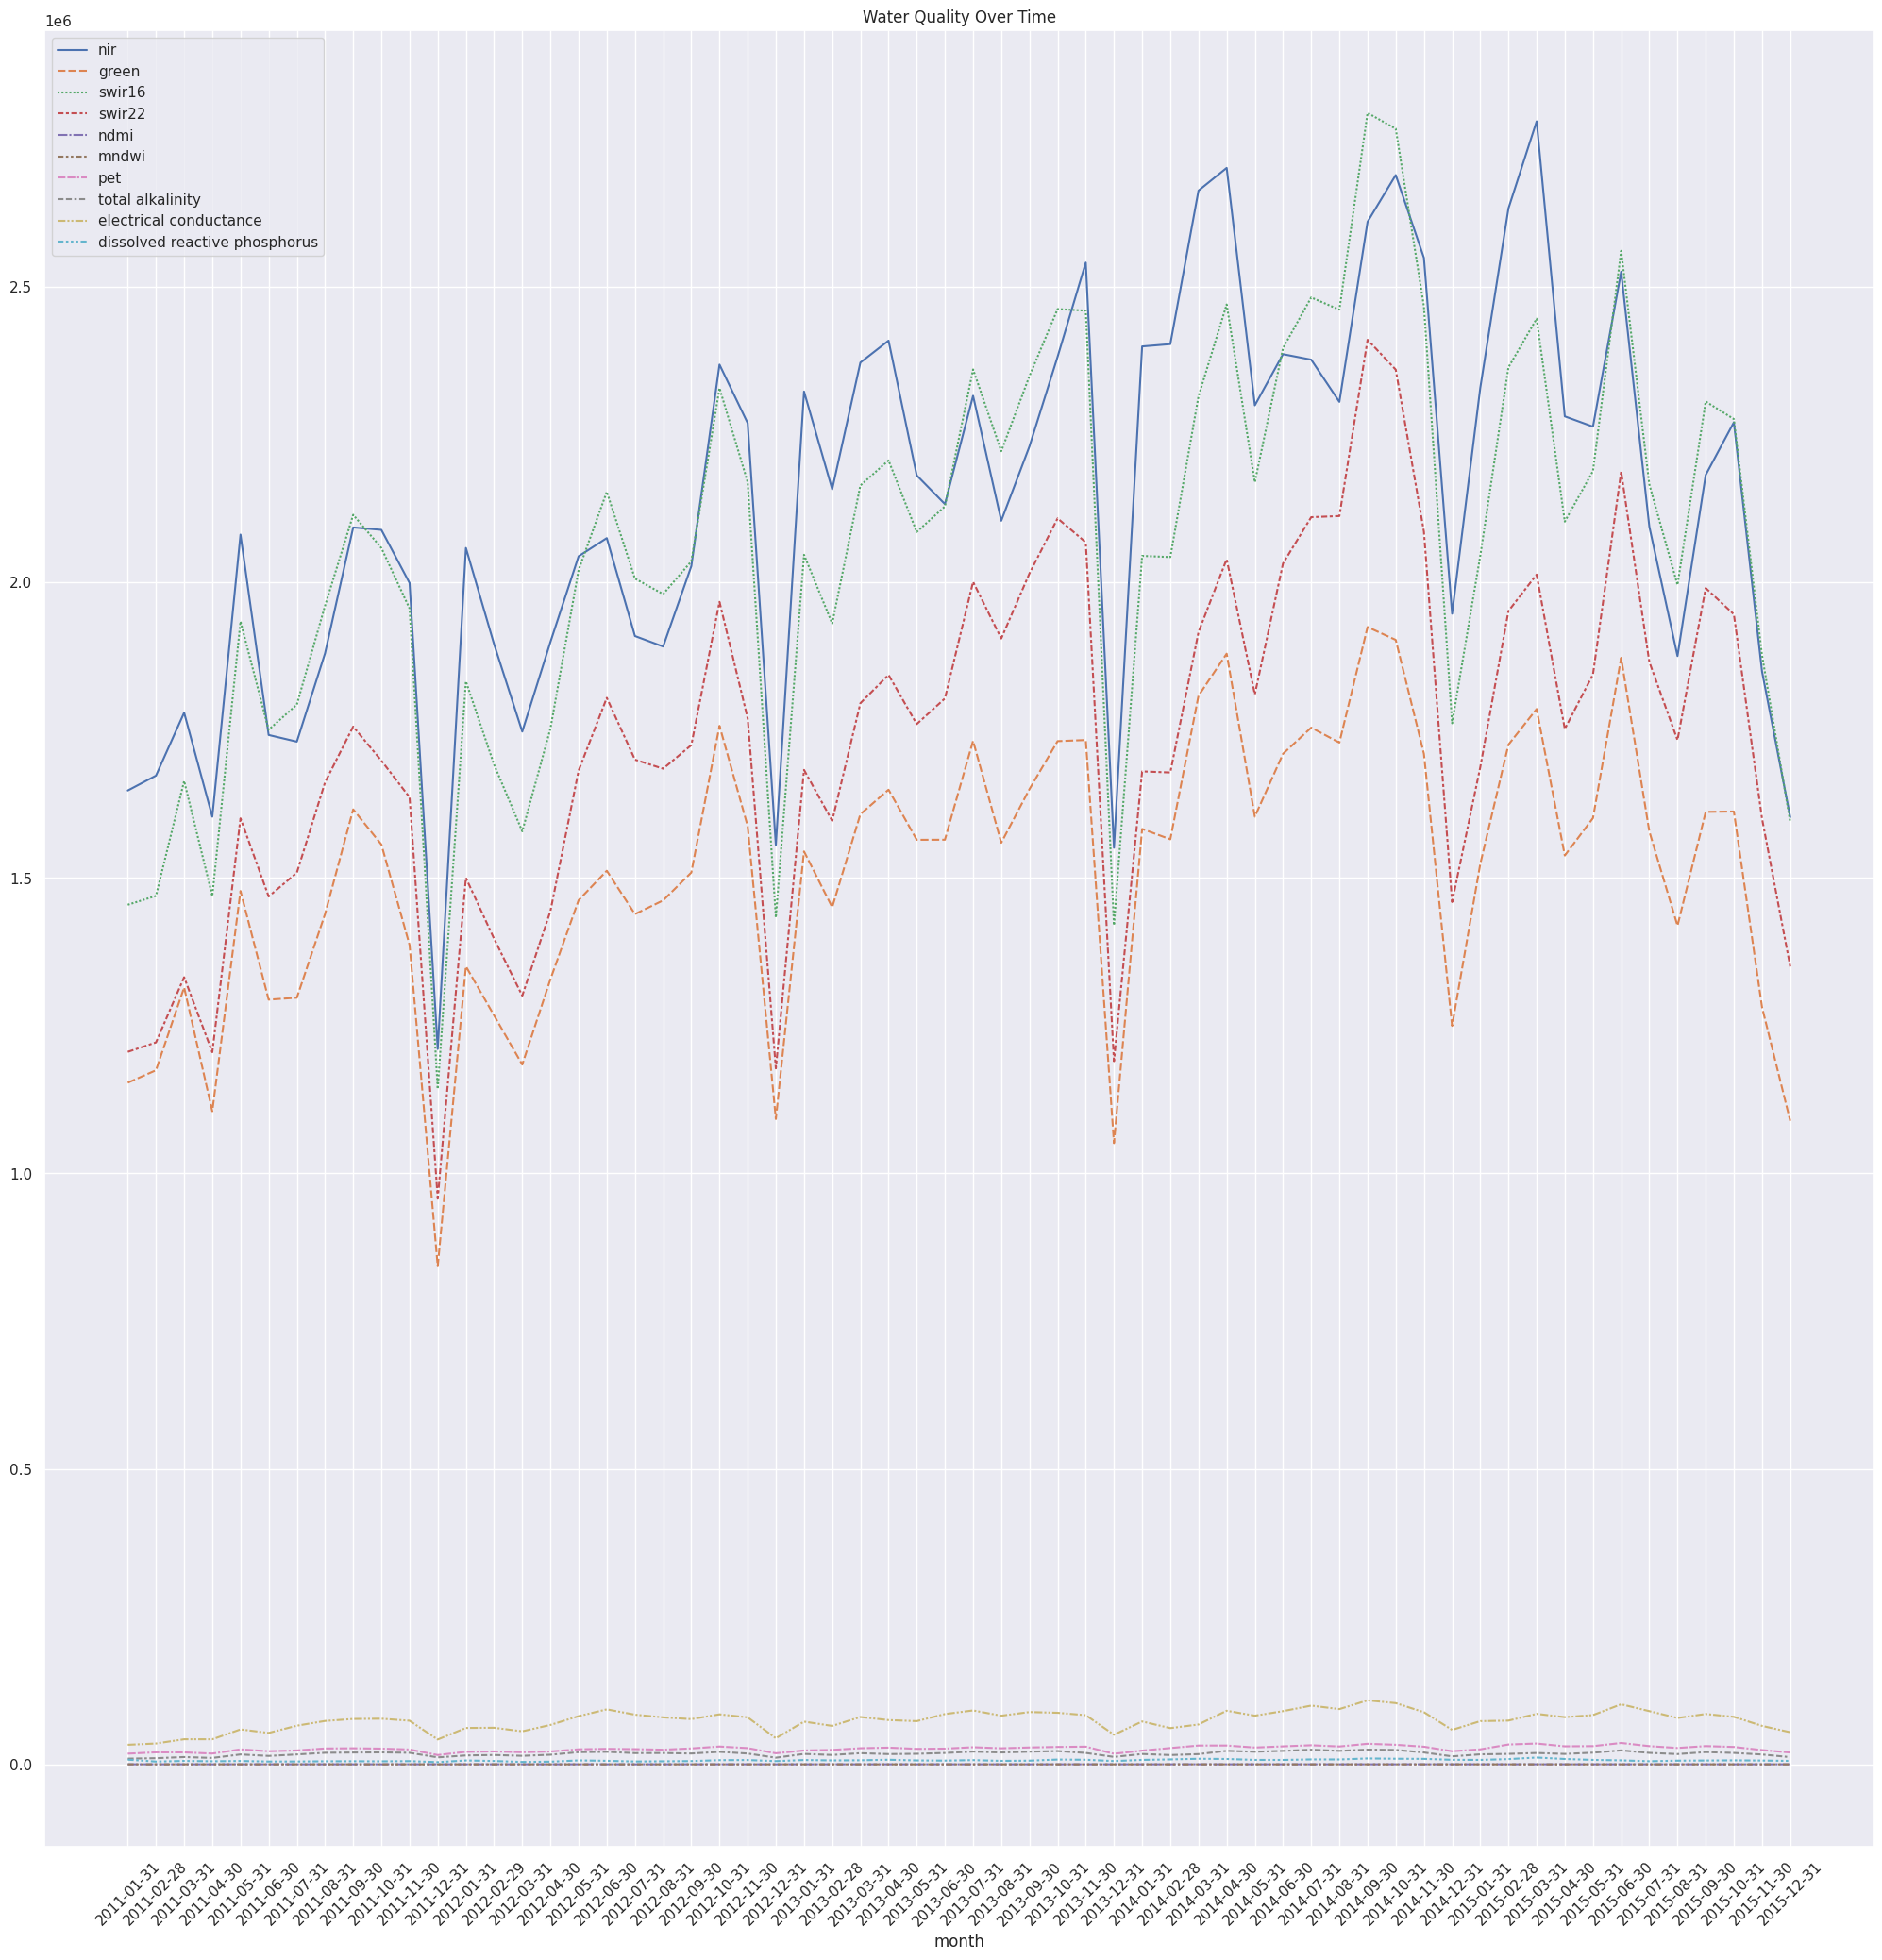

In [14]:
fig, ax = plt.subplots(figsize=(25, 25));
sns.lineplot(data=pivot_table)
plt.xticks(rotation=45)
plt.title('Water Quality Over Time');

### Correlation Matrix

In [15]:
# Select only numnerical columns
corr = df.select_dtypes(include=float).corr()
corr

,latitude,longitude,nir,green,swir16,swir22,ndmi,mndwi,pet,total alkalinity,electrical conductance,dissolved reactive phosphorus,pop_density_nn,distance_km_to_pd_cell
latitude,1.000000,0.639787,-0.040393,0.011184,0.116956,0.133295,-0.224581,-0.112853,-0.107510,0.320243,0.111837,0.258839,-0.037346,0.136838
longitude,0.639787,1.000000,0.031047,-0.008245,0.054137,0.041571,-0.044887,-0.083574,-0.590557,0.041433,-0.221109,0.016512,0.091271,0.097745
nir,-0.040393,0.031047,1.000000,0.564924,0.721484,0.628510,0.143543,-0.427569,-0.135331,0.017075,0.035750,-0.007180,-0.000503,0.066548
green,0.011184,-0.008245,0.564924,1.000000,0.598593,0.556784,-0.133780,0.128897,0.037861,0.058201,0.028307,0.009562,0.001592,0.011951
swir16,0.116956,0.054137,0.721484,0.598593,1.000000,0.952389,-0.554664,-0.671339,-0.000306,0.183232,0.137137,0.054800,-0.060017,0.110019
swir22,0.133295,0.041571,0.628510,0.556784,0.952389,1.000000,-0.634747,-0.618110,0.061599,0.201150,0.152529,0.062257,-0.050511,0.092397
ndmi,-0.224581,-0.044887,0.143543,-0.133780,-0.554664,-0.634747,1.000000,0.500269,-0.171230,-0.258788,-0.167710,-0.081299,0.095126,-0.077879
mndwi,-0.112853,-0.083574,-0.427569,0.128897,-0.671339,-0.618110,0.500269,1.000000,0.081856,-0.149456,-0.132735,-0.040099,0.076445,-0.147519
pet,-0.107510,-0.590557,-0.135331,0.037861,-0.000306,0.061599,-0.171230,0.081856,1.000000,0.267260,0.335060,0.072263,-0.056203,0.011173
total alkalinity,0.320243,0.041433,0.017075,0.058201,0.183232,0.201150,-0.258788,-0.149456,0.267260,1.000000,0.692318,0.318623,-0.061877,0.205821


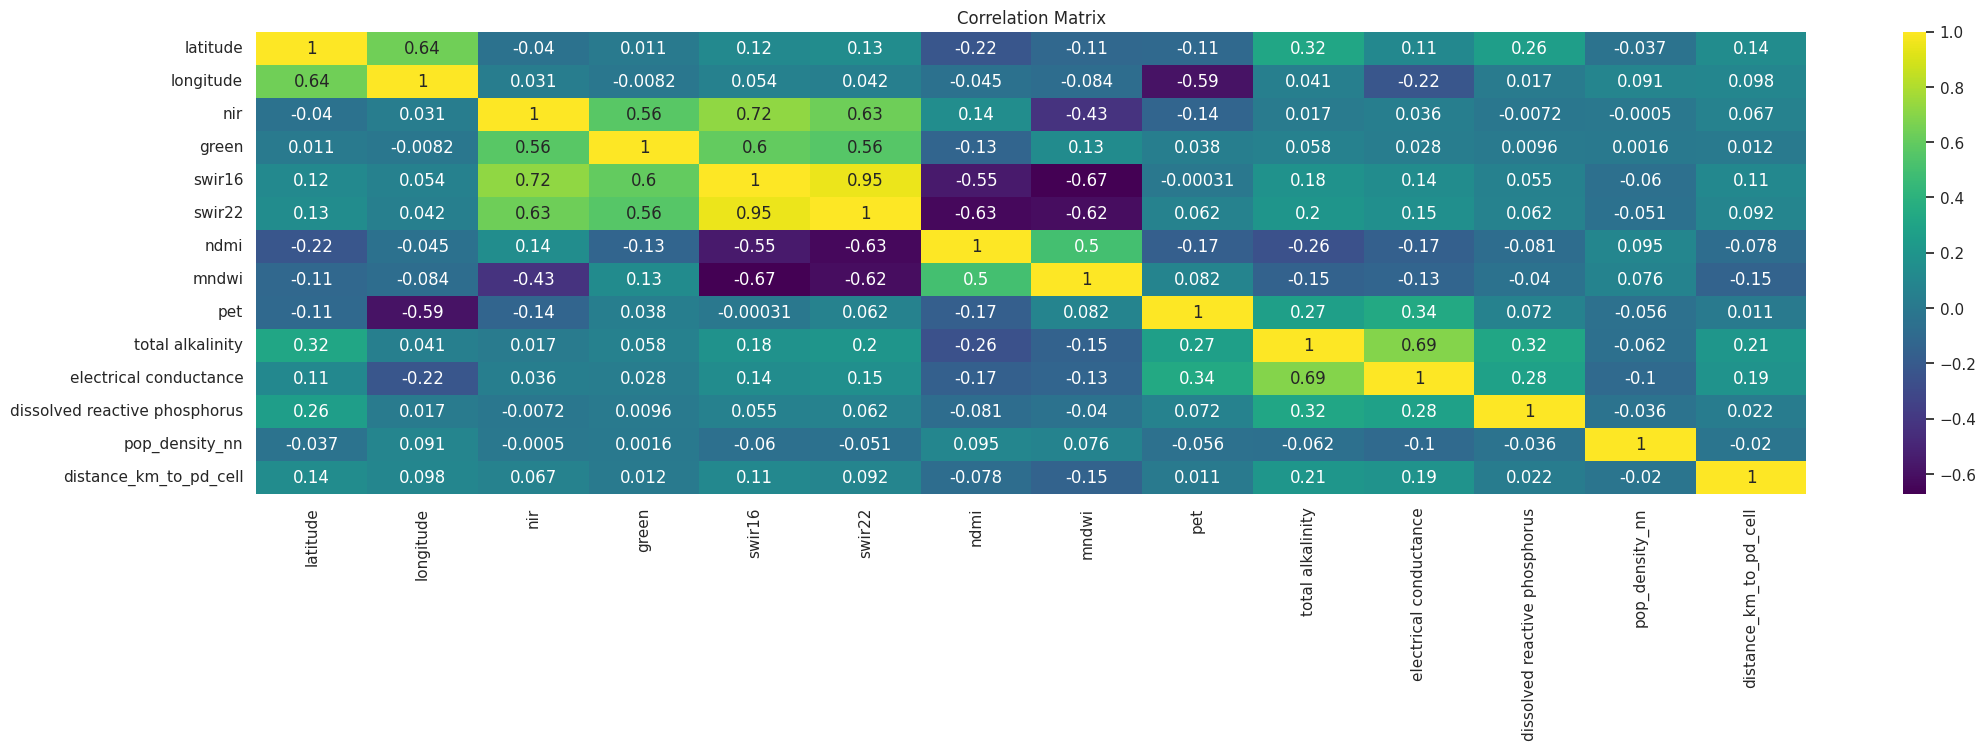

In [16]:
# Observe Patterns of Correlation is easier when plotted
fig, ax = plt.subplots(figsize=(25, 6));
sns.heatmap(corr, cmap='viridis', annot=True)
plt.title('Correlation Matrix');

#### Observation

There are generally no strong correlations. The satellite data (nir, green, swir16, swir22, ndmi, mndwi) have the strongest correlation among each other, suggesting they could have an effect on one another. Total alkalinity and Electrical have a realtively strong correlation. The strongest correlation in the dataset. We believe they are measuring similar parameters.

There are also noteable negative correlations present comparing ndmi/mndwi with swir16/swir22.

There is also some geografical correlation, for example, PET is negatively correlated with longitude while total alkalinity and DRP have a slightly positive correlation with latitude. 
- PET values are generally increasing from East to West.
- If you refer back to the map visualization above, you'll notice the encoded range of values for total alkalinity change ever so slightly when observing the data points' color from south to north.

Potential Evapotranspiration - usually measured indirectly using other climactic factors, the amount of Water Volume Evapotranspired from a sample location (mm day<sup>−1</sup>). PET is dependent on temperature and vapor pressure. As the global temperature increases PET and humidity increase with it.  
Relative humidity could be merged with our dataset in the future for verification.


https://en.wikipedia.org/wiki/Potential_evapotranspiration

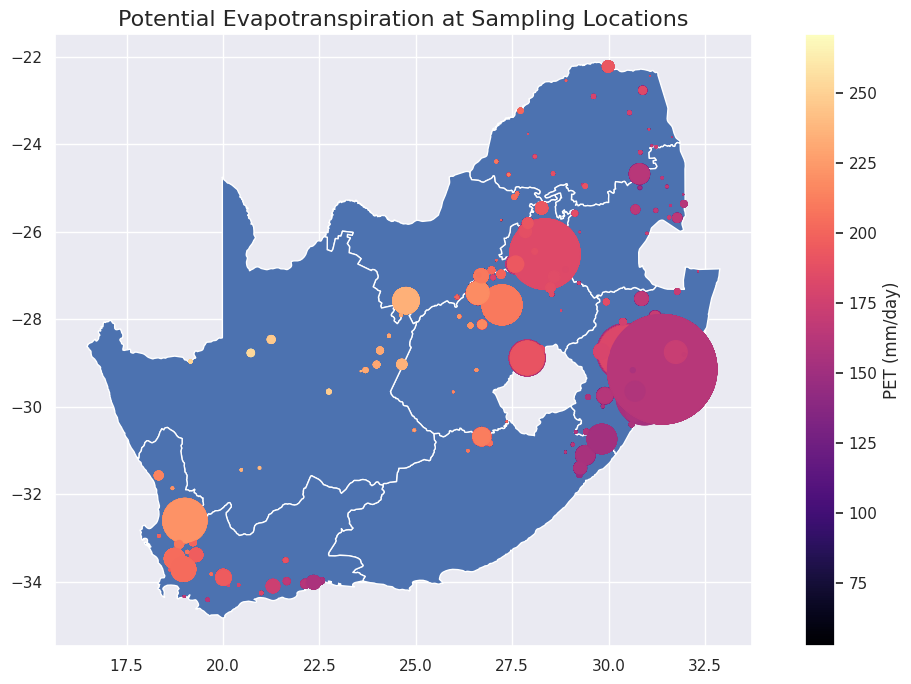

In [47]:
# Plot
fig, ax = plt.subplots(figsize=(11, 7))

provinces.plot(ax=ax)
gdf.plot(column='pet', ax=ax, marker='o', markersize=gdf['pop_density_nn'], cmap='magma', legend=True, legend_kwds={'label':'PET (mm/day)'})

# ax.set_axis_off()
plt.title('Potential Evapotranspiration at Sampling Locations', fontsize=16)
plt.tight_layout()
plt.show();

In [48]:
df['pet'].describe()

count    9093.000000
mean      174.685562
std        29.055385
min        52.700000
25%       155.700000
50%       172.200000
75%       192.900010
max       270.800020
Name: pet, dtype: float64